EDA for the task, Exercise 2

What this notebook contains:
EDA Technique A (Basic Statistical Profiling + Noise/Artifacts):
  - Class distribution bar chart
  - Token length distribution (overall + by class)
  - Summary table: min/mean/median/p95/max token counts (overall + by class)
  - Duplicate analysis table (exact duplicates + near-duplicates via MinHash-ish hashing)
  - HTML / special-character artifact counts table

EDA Technique B (Lexical Analysis):
  - Class-conditional log-odds top unigrams & bigrams (tables)
  - Stopword density distribution (overall + by class)
  - POS analysis


In [54]:
import spacy
import pandas as pd
import numpy as np
import re
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 20)

# ---------- Load dataset ----------
DATA_TSV = "../data/dontpatronizeme_pcl.tsv"

df = pd.read_csv(
    DATA_TSV,
    sep="\t",
    header=None,
    names=["par_id", "art_id", "keyword", "country", "text", "label"],
    engine="python",
    quoting=3,
    on_bad_lines="skip"
)

# Basic cleaning
df = df.dropna(subset=["par_id", "text", "label"])
df["par_id"] = pd.to_numeric(df["par_id"], errors="coerce")
df["label"] = pd.to_numeric(df["label"], errors="coerce")
df = df.dropna()
df["par_id"] = df["par_id"].astype(int)
df["label"] = df["label"].astype(int)

df["label_bin"] = df["label"].apply(lambda x: 0 if x in [0,1] else 1)
print(df["label_bin"].value_counts())

print("Dataset shape:", df.shape)
df.head()

label_bin
0    9475
1     993
Name: count, dtype: int64
Dataset shape: (10468, 7)


,par_id,art_id,keyword,country,text,label,label_bin
3,1,@@24942188,hopeless,ph,"We 're living in times of absolute insanity , ...",0,0
4,2,@@21968160,migrant,gh,"In Libya today , there are countless number of...",0,0
5,3,@@16584954,immigrant,ie,"""White House press secretary Sean Spicer said ...",0,0
6,4,@@7811231,disabled,nz,Council customers only signs would be displaye...,0,0
7,5,@@1494111,refugee,ca,""""""" Just like we received migrants fleeing El ...",0,0


EDA Technique A

Class distribution

label
0    8528
1     947
2     144
3     458
4     391
Name: count, dtype: int64


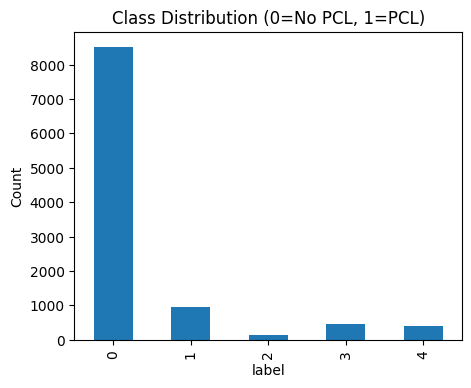

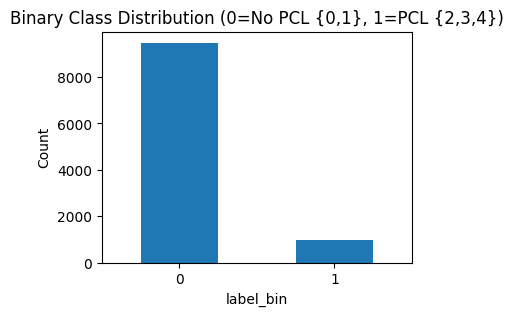

In [55]:
class_counts = df["label"].value_counts().sort_index()
print(class_counts)

plt.figure(figsize=(5,4))
class_counts.plot(kind="bar")
plt.title("Class Distribution (0=No PCL, 1=PCL)")
plt.ylabel("Count")
plt.show()

bin_counts = df["label_bin"].value_counts().sort_index()
plt.figure(figsize=(4,3))
bin_counts.plot(kind="bar")
plt.title("Binary Class Distribution (0=No PCL {0,1}, 1=PCL {2,3,4})")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

Token Length Analysis

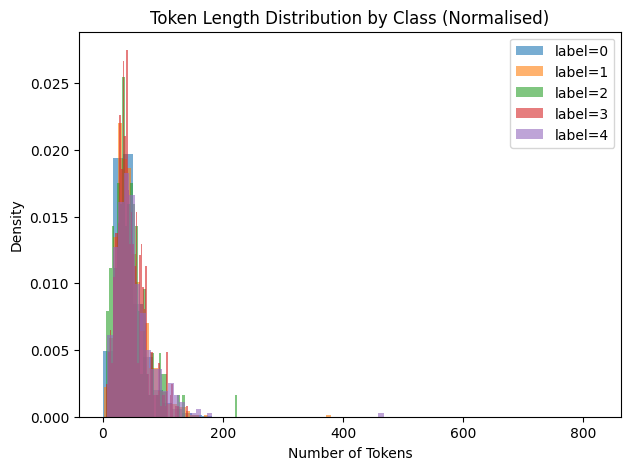

In [ ]:
plt.figure(figsize=(7,5))

for lab in sorted(df["label"].unique()):
    subset = df[df["label"]==lab]["n_tokens"]
    plt.hist(
        subset,
        bins=50,
        alpha=0.6,
        label=f"label={lab}",
        density=True
    )

plt.legend()
plt.title("Token Length Distribution by Class (Normalised)")
plt.xlabel("Number of Tokens")
plt.ylabel("Density")
plt.show()

Vocabulary Size and Top Tokens

In [57]:
vocab = Counter()
for tokens in df["tokens"]:
    vocab.update(tokens)

print("Vocabulary Size:", len(vocab))

pd.DataFrame(vocab.most_common(20), columns=["Token", "Count"])

Vocabulary Size: 30056


,Token,Count
0,the,25891
1,to,14155
2,of,13936
3,and,12850
4,in,11051
5,a,9217
6,for,4895
7,that,4837
8,is,4512
9,are,3407


Noise Size and Artifact Detection

In [58]:
# Duplicate detection
duplicate_texts = df["text"].duplicated().sum()
print("Number of duplicate texts:", duplicate_texts)

# HTML artifacts
html_count = df["text"].str.contains("<[^>]+>", regex=True).sum()
print("Texts containing HTML tags:", html_count)

# Extremely short / long
short_texts = (df["n_tokens"] < 10).sum()
long_texts = (df["n_tokens"] > 512).sum()

print("Very short texts (<10 tokens):", short_texts)
print("Very long texts (>512 tokens):", long_texts)


Number of duplicate texts: 0
Texts containing HTML tags: 401
Very short texts (<10 tokens): 205
Very long texts (>512 tokens): 1


EDA Technique B

Stopword Density

In [59]:
STOPWORDS = set("""
a an the and or but if while of at by for with about against between into through during before after
above below to from up down in out on off over under again further then once here there when where why
how all any both each few more most other some such no nor not only own same so than too very
can will just don should now is am are was were be been being have has had do does did
i me my myself we our ours ourselves you your yours yourself yourselves he him his himself she her hers herself
it its itself they them their theirs themselves what which who whom this that these those
""".split())

def stopword_density(tokens):
    if not tokens:
        return 0
    return sum(t in STOPWORDS for t in tokens) / len(tokens)

df["stopword_density"] = df["tokens"].apply(stopword_density)
df.groupby("label")["stopword_density"].describe()



,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,8528.0,0.394615,0.089502,0.0,0.341463,0.396226,0.452624,0.750000
1,947.0,0.420100,0.083269,0.0,0.366667,0.423913,0.476732,0.666667
2,144.0,0.403378,0.093772,0.0,0.350845,0.400000,0.458750,0.647059
3,458.0,0.432436,0.082381,0.1,0.376078,0.436572,0.487006,0.655172
4,391.0,0.442656,0.086783,0.1,0.387097,0.448276,0.500000,0.666667


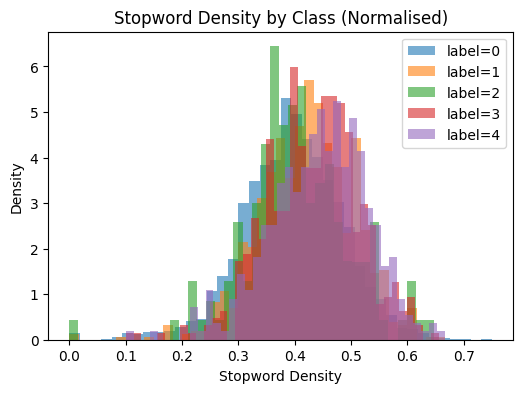

In [ ]:
plt.figure(figsize=(6,4))

for lab in sorted(df["label"].unique()):
    subset = df[df["label"]==lab]["stopword_density"]
    plt.hist(
        subset,
        bins=40,
        alpha=0.6,
        label=f"label={lab}",
        density=True
    )

plt.legend()
plt.title("Stopword Density by Class (Normalised)")
plt.xlabel("Stopword Density")
plt.ylabel("Density")
plt.show()

Top N-grams per Class

In [ ]:
# Get sorted indices
sorted_idx = np.argsort(log_ratio)

# Largest and smallest log ratios
top_pos_idx = sorted_idx[::-1][:20]
top_neg_idx = sorted_idx[:20]

# Build table
comparison_df = pd.DataFrame({
    "Top PCL n-grams": feature_names[top_pos_idx],
    "Top No-PCL n-grams": feature_names[top_neg_idx]
})

display(comparison_df)


,Top PCL n-grams,Top No-PCL n-grams
0,the dignity,immigrants from
1,the hungry,anti immigrant
2,prayer,the report
3,the cycle,released
4,teresa,are more
5,dole,immigrants to
6,god 's,issued
7,smiles,compared
8,faces of,technology
9,above all,influx


Category label exploration

In [62]:
def eda_categories(df_main: pd.DataFrame) -> None:
    """
    Uses train/dev par_id label vectors to explore the 7 PCL categories.
    This is optional support information; your main task remains binary.
    """
    paths = []
    if os.path.exists(TRAIN_CATS):
        paths.append(TRAIN_CATS)
    if os.path.exists(DEV_CATS):
        paths.append(DEV_CATS)

    if not paths:
        print("[WARN] No category label files found. Skipping category EDA.")
        return

    parts = []
    for p in paths:
        d = load_category_file(p)
        d["source"] = os.path.basename(p)
        parts.append(d)

    cats = pd.concat(parts, ignore_index=True)
    # count category positives
    cat_counts = cats[PCL_CATEGORIES].sum().sort_values(ascending=False)
    cat_counts.to_csv(os.path.join(OUT_DIR, "table_category_counts.csv"))

    plt.figure()
    cat_counts.plot(kind="bar")
    plt.title("PCL Category Counts (Auxiliary Labels)")
    plt.xlabel("Category")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "fig_category_counts.png"), dpi=200)
    plt.close()

    # Join back to main to see how categories map to your binary labels (sanity check)
    merged = df_main[["par_id", "label"]].merge(cats[["par_id"] + PCL_CATEGORIES + ["any_cat"]], on="par_id", how="left")
    merged.to_csv(os.path.join(OUT_DIR, "table_main_with_categories_join.csv"), index=False)

    # How often any_cat aligns with label==1
    align = pd.crosstab(merged["label"], merged["any_cat"], dropna=False)
    align.to_csv(os.path.join(OUT_DIR, "table_binary_vs_any_category_crosstab.csv"))

Semantic/Syntactic Cell: POS distribution by class

,POS,PCL_prop,NoPCL_prop,diff_PCL_minus_NoPCL
0,PROPN,0.067762,0.079516,-0.011754
1,PRON,0.055969,0.044280,0.011689
2,NUM,0.011443,0.018669,-0.007226
3,PUNCT,0.134628,0.127552,0.007076
4,NOUN,0.191200,0.196094,-0.004894
5,CCONJ,0.032499,0.029308,0.003191
6,VERB,0.102226,0.099336,0.002890
7,ADP,0.113183,0.116017,-0.002834
8,AUX,0.054081,0.051516,0.002565
9,ADJ,0.073931,0.076352,-0.002421


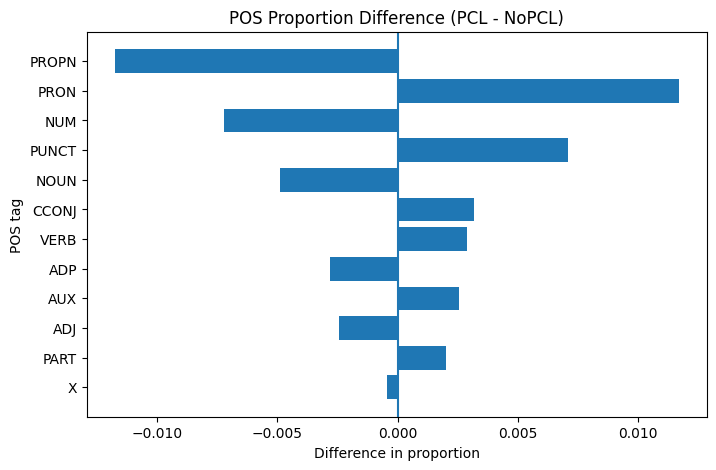

In [74]:
nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"])

pos_mask = (df["label_bin"] == 1).to_numpy()
neg_mask = (df["label_bin"] == 0).to_numpy()

# Stratified sampling for speed (keeps class comparison fair)
df_pos_s = df_pos.sample(len(df_pos), random_state=42) if len(df_pos) > 0 else df_pos
df_neg_s = df_neg.sample(len(df_neg), random_state=42) if len(df_neg) > 0 else df_neg
df_s = pd.concat([df_pos_s, df_neg_s], ignore_index=True)

def pos_distribution(texts):
    counts = {}
    total = 0
    for doc in nlp.pipe(texts, batch_size=64):
        for tok in doc:
            if tok.is_space:
                continue
            pos = tok.pos_
            counts[pos] = counts.get(pos, 0) + 1
            total += 1
    # normalize to proportions
    return {k: v / total for k, v in counts.items()} if total > 0 else {}

pos_dist_pcl = pos_distribution(df_pos_s["text"].astype(str).tolist())
pos_dist_nopcl = pos_distribution(df_neg_s["text"].astype(str).tolist())

# Combine into a table
all_tags = sorted(set(pos_dist_pcl) | set(pos_dist_nopcl))
table = pd.DataFrame({
    "POS": all_tags,
    "PCL_prop": [pos_dist_pcl.get(t, 0.0) for t in all_tags],
    "NoPCL_prop": [pos_dist_nopcl.get(t, 0.0) for t in all_tags],
})
table["diff_PCL_minus_NoPCL"] = table["PCL_prop"] - table["NoPCL_prop"]

# Show the most different POS tags (absolute difference)
table_sorted = table.reindex(table["diff_PCL_minus_NoPCL"].abs().sort_values(ascending=False).index).reset_index(drop=True)

display(table_sorted.head(15))

# Plot top differences
top_k = 12

# reverse for nicer bar ordering
plot_df = table_sorted.head(top_k).iloc[::-1]

plt.figure(figsize=(8, 5))
plt.barh(plot_df["POS"], plot_df["diff_PCL_minus_NoPCL"])
plt.title("POS Proportion Difference (PCL - NoPCL)")
plt.xlabel("Difference in proportion")
plt.ylabel("POS tag")
plt.axvline(0)
plt.show()